# **종합실습3 : Multi-Class - Fashion MNIST**

* 패션 아이템 이미지 10가지 분류하기
    * 데이터 : 이미지(1, 32, 32) 6만장
    * 10가지 클래스로 분류하기 위한 모델 생성

![](https://www.researchgate.net/publication/346405197/figure/fig3/AS:962581560848384@1606508736352/Examples-of-Fashion-MNIST-dataset.ppm)


## **1.환경준비**

### (1) 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # long = int64
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [7]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### (4) 데이터 셋

#### 1) 다운로드

In [8]:
train_dataset = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 154kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.0MB/s]


#### 2) 데이터셋 정보

* 데이터셋 일반 정보

In [9]:
train_dataset, test_dataset

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

* 데이터셋의 x와 y

In [10]:
train_dataset.data.shape, train_dataset.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

* y(target)의 클래스

In [11]:
classes = train_dataset.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

* 데이터 1건

In [12]:
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

* 데이터 이미지 확인

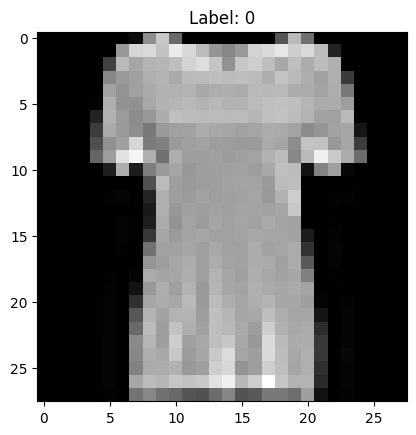

In [13]:
n = 10
image, label = train_dataset.data[n], train_dataset.targets[n]

# 이미지 시각화
plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.show()

## **2.데이터 준비**

* 다운 받은 데이터셋은 다음의 전처리가 완료됨
    * x, y가 분리
    * train, test 분리
    * 스케일링

### (1) train은 데이터로더로 생성

In [14]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)

In [15]:
# 첫번째 배치만 로딩해서 살펴보기
for X, y in train_dataloader:
    print(f"Shape of X [batch, channels, height, width]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [batch, channels, height, width]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


### (2) validation, test 준비
* 데이터셋 분할
    * validation : 학습시, 에포크마다 성능 검증용
    * test : 모델 생성 후 최종 검증용
* dataset의 data 속성으로 데이터를 뽑으면 원본데이터가 나옵니다.
    * 스케일링 안된 데이터
    * 5000, 28, 28 : 3차원 데이터셋
* 그래서 모델링에 사용하려면 두가지 전처리를 다시 해줘야 함
    * 스케일링 : 원본데이터가 0~255 까지 숫자이므로, 255로 나눠주면 됨
    * 4차원 변환 : 5000, 1, 28, 28

#### 1) 데이터 분할 : test --> val, test

In [16]:
x_val, x_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

In [17]:
x_val.shape, y_val.shape

(torch.Size([5000, 28, 28]), torch.Size([5000]))

#### 2) 스케일링

In [18]:
x_val = x_val / 255
x_test = x_test/ 255

#### 3) 3차원 데이터셋 --> 4차원 데이터셋
* 여기서 꼭 필요한 작업은 아닙니다.
* 하지만, 잠시 후에 배울 CNN 모델링에서...
    * 이미지 한장의 구조는, [채널, 세로픽셀 수, 가로픽셀 수] 입니다.
        * 채널 : 흑백 = 1, 컬러 = 3
* 그러므로 여기서도 동일한 전처리를 수행합니다.

In [19]:
x_val = x_val.view(5000, 1, 28, 28)  # [1 * 28 * 28 이미지 5000장] 구조로 변환.
x_test = x_test.view(5000, 1, 28, 28)

print(x_val.shape, x_test.shape)

torch.Size([5000, 1, 28, 28]) torch.Size([5000, 1, 28, 28])


## **3.모델링**
* 다양한 구조로 모델을 2개 이상 생성하고 성능을 평가해 봅시다.


### (1) 모델1

In [20]:
n_feature = 28 * 28
n_class = 10

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_feature, 258),
    nn.ReLU(),
    nn.Linear(258, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, n_class),

).to(device)

In [21]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [23]:
epochs = 10

tr_loss_list, val_loss_list = [], []

for i in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {i+1}/{epochs}, Train Loss: {tr_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/10, Train Loss: 0.3790, Val Loss: 0.4268
Epoch 2/10, Train Loss: 0.3363, Val Loss: 0.3894
Epoch 3/10, Train Loss: 0.3119, Val Loss: 0.3902
Epoch 4/10, Train Loss: 0.2928, Val Loss: 0.3787
Epoch 5/10, Train Loss: 0.2764, Val Loss: 0.3662
Epoch 6/10, Train Loss: 0.2620, Val Loss: 0.3715
Epoch 7/10, Train Loss: 0.2507, Val Loss: 0.3638
Epoch 8/10, Train Loss: 0.2391, Val Loss: 0.3729
Epoch 9/10, Train Loss: 0.2300, Val Loss: 0.3605
Epoch 10/10, Train Loss: 0.2210, Val Loss: 0.3695


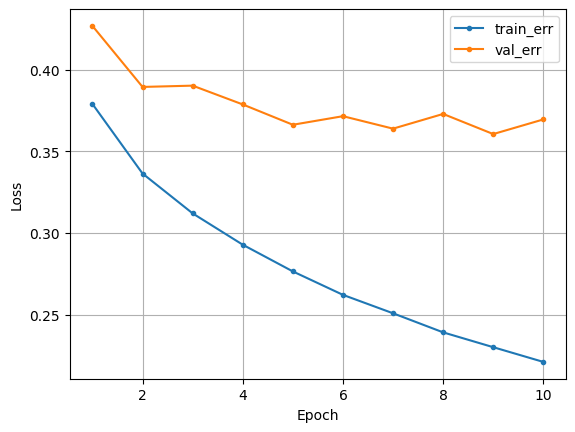

In [24]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [25]:
pred[:5]

tensor([[-7.7623e+00, -8.7190e+00, -1.2914e+01, -7.5536e+00, -6.1871e+00,
         -2.5902e+00, -9.1588e+00, -1.0845e+00, -1.1612e+01,  5.3235e+00],
        [-1.4144e+00, -1.0188e+01,  5.6215e+00, -5.9599e+00,  2.8597e+00,
         -1.4305e+01,  1.2994e+00, -2.1602e+01, -5.5516e+00, -1.2118e+01],
        [-3.2883e+00,  2.8131e+01, -6.7924e+00, -9.6570e+00, -9.7868e+00,
         -2.4700e+01, -4.1719e+00, -1.9667e+01, -1.6707e+01, -3.8901e+01],
        [-6.0886e+00,  2.4374e+01, -4.0924e+00, -6.5589e+00, -6.0026e+00,
         -2.1017e+01, -3.2000e+00, -1.6560e+01, -1.7775e+01, -3.4318e+01],
        [ 1.5454e+00, -8.5230e+00,  3.7273e-02, -2.0092e+00, -6.6100e-01,
         -6.5656e+00,  4.0144e+00, -1.6574e+01, -2.5962e+00, -5.4835e+00]],
       device='cuda:0')

In [26]:
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)
pred

array([9, 2, 1, ..., 9, 0, 7])

In [28]:
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       507
           1       0.95      0.98      0.96       481
           2       0.83      0.67      0.74       521
           3       0.89      0.85      0.87       500
           4       0.72      0.86      0.78       521
           5       0.97      0.96      0.97       485
           6       0.72      0.65      0.68       482
           7       0.94      0.97      0.96       500
           8       0.93      0.99      0.96       526
           9       0.97      0.96      0.97       477

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



### (2) 모델2

In [31]:
n_feature = 28 * 28
n_class = 10

model2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_feature, 258),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(258, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, n_class),
).to(device)

In [32]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)

In [33]:
epochs = 10
tr_loss_list, val_loss_list = [], []

for i in range(epochs):
    tr_loss = train(train_dataloader, model2, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model2, loss_fn, device)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {i+1}/{epochs}, Train Loss: {tr_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/10, Train Loss: 0.6120, Val Loss: 0.4554
Epoch 2/10, Train Loss: 0.4133, Val Loss: 0.4288
Epoch 3/10, Train Loss: 0.3713, Val Loss: 0.3895
Epoch 4/10, Train Loss: 0.3494, Val Loss: 0.3575
Epoch 5/10, Train Loss: 0.3325, Val Loss: 0.3606
Epoch 6/10, Train Loss: 0.3173, Val Loss: 0.3628
Epoch 7/10, Train Loss: 0.3050, Val Loss: 0.3559
Epoch 8/10, Train Loss: 0.2952, Val Loss: 0.3489
Epoch 9/10, Train Loss: 0.2855, Val Loss: 0.3465
Epoch 10/10, Train Loss: 0.2773, Val Loss: 0.3459


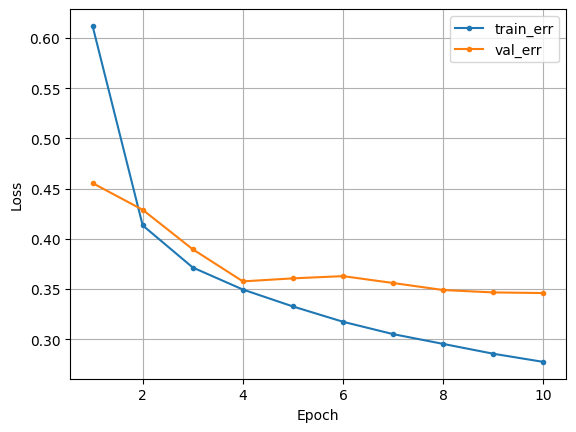

In [34]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [35]:
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)
pred

array([9, 2, 1, ..., 9, 0, 7])

In [36]:
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       507
           1       0.98      0.98      0.98       481
           2       0.82      0.72      0.77       521
           3       0.87      0.88      0.88       500
           4       0.77      0.82      0.79       521
           5       0.97      0.97      0.97       485
           6       0.71      0.62      0.66       482
           7       0.94      0.97      0.95       500
           8       0.96      0.98      0.97       526
           9       0.97      0.94      0.96       477

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.87      5000
weighted avg       0.87      0.88      0.87      5000



### (3) 모델3

In [37]:
model3 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, n_class),
).to(device)


In [38]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001)

In [39]:
epochs = 10
tr_loss_list, val_loss_list = [], []

for i in range(epochs):
    tr_loss = train(train_dataloader, model3, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model3, loss_fn, device)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {i+1}/{epochs}, Train Loss: {tr_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/10, Train Loss: 0.4062, Val Loss: 0.3846
Epoch 2/10, Train Loss: 0.2824, Val Loss: 0.3806
Epoch 3/10, Train Loss: 0.2435, Val Loss: 0.3216
Epoch 4/10, Train Loss: 0.2129, Val Loss: 0.2942
Epoch 5/10, Train Loss: 0.1930, Val Loss: 0.2745
Epoch 6/10, Train Loss: 0.1724, Val Loss: 0.2892
Epoch 7/10, Train Loss: 0.1542, Val Loss: 0.2600
Epoch 8/10, Train Loss: 0.1381, Val Loss: 0.2766
Epoch 9/10, Train Loss: 0.1252, Val Loss: 0.2931
Epoch 10/10, Train Loss: 0.1115, Val Loss: 0.3013


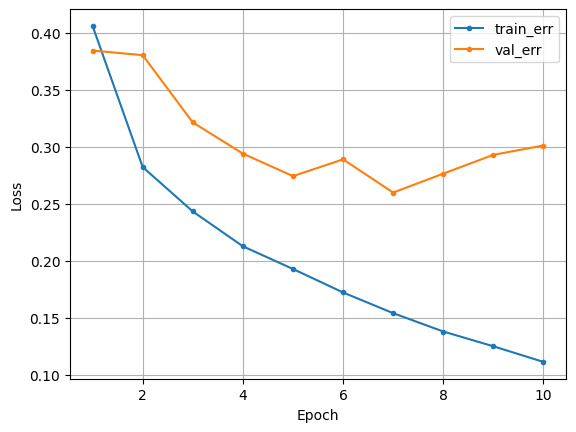

In [40]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [41]:
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)
pred

array([9, 2, 1, ..., 9, 0, 7])

In [42]:
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

           0       0.76      0.96      0.85       507
           1       0.99      0.98      0.99       481
           2       0.86      0.87      0.87       521
           3       0.92      0.89      0.90       500
           4       0.84      0.88      0.86       521
           5       0.99      0.98      0.98       485
           6       0.86      0.60      0.71       482
           7       0.96      0.97      0.97       500
           8       0.98      0.98      0.98       526
           9       0.97      0.97      0.97       477

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000

